In [ ]:
# This is the GO and GSEA analysis for the basic multimapping counts

In [1]:
from goatools.obo_parser import GODag
from goatools.associations import read_ncbi_gene2go
from goatools.go_enrichment import GOEnrichmentStudy
import mygene
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Load the vsd_counts from saved from the previous analysis
vsd_counts = pd.read_csv('DESeq_vsd_basic_multimapping_counts.csv', index_col = 0)
Gene_symbols_background = vsd_counts
Gene_symbols_background

,B2 naive,B11 naive,F12 naive,C3 naive,B10 naive,E11 naive,B2 day 5,B11 day 5,F12 day 5,C3 day 5,B10 day 5,E11 day 5,B2 day 10,B11 day 10,F12 day 10,C3 day 10,B10 day 10,E11 day 10
symbol,,,,,,,,,,,,,,,,,,
WASH7P,8.923579,8.894342,8.929423,8.777034,8.936836,8.989217,9.621634,9.603879,9.051459,9.316333,9.492912,9.386037,8.748866,8.926380,8.636121,8.769469,8.865426,8.842633
nan ENSG00000241860,7.789795,7.602188,7.770000,7.802209,7.682072,8.041420,8.800518,8.638510,8.977231,8.385018,8.157716,8.828741,8.300789,8.476177,7.969442,8.067598,7.981038,8.308832
CICP27,6.863774,6.601329,6.329555,6.680137,6.633362,6.846638,6.956795,7.097002,6.937396,6.781918,6.701287,6.798269,6.940446,7.284466,6.851483,6.770522,6.851387,6.973230
nan ENSG00000308579,6.756229,6.988494,6.786541,6.803318,6.990411,6.937682,8.168200,8.346719,7.718018,7.700524,7.836103,7.778442,7.632577,7.996094,7.679121,7.276981,7.135428,7.585950
nan ENSG00000268903,9.120883,9.060121,8.185156,8.617325,8.308968,8.827124,10.024622,10.629279,9.942016,9.815915,9.911616,9.884512,8.909138,9.798267,9.712776,9.076767,9.155516,9.072970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ND4,17.297849,17.975945,17.845070,17.724161,17.871882,17.353774,18.514432,18.547833,18.763700,18.394567,18.276055,18.347109,17.833873,18.167845,17.048108,18.123352,17.885959,17.858512
ND5,16.046588,16.312353,16.748165,16.403031,16.469305,16.064004,16.749009,16.301584,16.587981,16.568507,16.510037,16.547773,16.424596,16.251060,15.803795,16.494520,16.309313,16.403713
ND6,13.691067,13.992489,14.441675,14.053990,14.205421,13.802602,14.458625,13.969646,14.340641,14.225155,14.227296,14.282368,14.137774,13.883366,13.517639,14.168306,14.016719,14.092467


In [5]:
# Load the DEG_results from the DESeq2
DEG_results = pd.read_csv('Day_10_DEG_df.csv', index_col = 0)
DEG_results

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
GeneID,,,,,,
WASH7P,435.021784,0.063040,0.177744,0.354667,0.722839,0.948424
nan ENSG00000241860,207.690701,-0.204948,0.268906,-0.762156,0.445967,0.858362
CICP27,32.186670,-0.457597,0.424983,-1.076741,0.281596,0.759498
nan ENSG00000308579,94.246903,-0.790661,0.315992,-2.502156,0.012344,0.238582
nan ENSG00000268903,608.638480,-0.503366,0.322131,-1.562613,0.118144,0.581442
...,...,...,...,...,...,...
ND4,272422.517216,0.205953,0.241587,0.852501,0.393936,0.832502
ND5,86790.014663,0.222051,0.196828,1.128145,0.259259,0.744215
ND6,17494.037394,0.227004,0.202284,1.122201,0.261777,0.745530


In [6]:
# Extract all genes with pvalue < 0.05, log2foldchange > or < than 1
DEG_results['significant'] = DEG_results['padj'] < 0.05
DEG_results['TwoFoldChange'] = (DEG_results['log2FoldChange'] >= 1) | (DEG_results['log2FoldChange'] <= -1)
DEG_results['SignificantLargeChange'] = (DEG_results['significant'] == True) & (DEG_results['TwoFoldChange'] == True)
Significant_DEGs_all = DEG_results[DEG_results['SignificantLargeChange']]
Significant_DEGs_all

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,significant,TwoFoldChange,SignificantLargeChange
GeneID,,,,,,,,,
FNDC10,1160.299158,-1.026700,0.252327,-4.068922,4.723115e-05,0.006835,True,True,True
TNFRSF1B,1064.827356,1.501202,0.302480,4.962974,6.942204e-07,0.000434,True,True,True
MAN1C1,2130.027934,-1.089149,0.301680,-3.610282,3.058644e-04,0.026954,True,True,True
RPS27P9,200.459856,-1.040493,0.299167,-3.477965,5.052363e-04,0.037789,True,True,True
DENND2D,39.482395,2.125652,0.462862,4.592410,4.381556e-06,0.001560,True,True,True
...,...,...,...,...,...,...,...,...,...
STS,954.151446,1.669743,0.395530,4.221531,2.426488e-05,0.004584,True,True,True
DDX53,157.418824,1.701487,0.446861,3.807644,1.402968e-04,0.015806,True,True,True
LINC03099,20.952392,2.236571,0.548759,4.075688,4.587853e-05,0.006749,True,True,True


In [7]:
# Seperate signifcant DEGs into upregulated and downregulated
Gene_symbols_upregulated_DEGs = Significant_DEGs_all[Significant_DEGs_all['log2FoldChange'] > 0]
Gene_symbols_downregulated_DEGs = Significant_DEGs_all[Significant_DEGs_all['log2FoldChange'] < 0]

In [8]:
# Load directed acyclic graph (DAG) file and Gene to GO mapping file
obodag = GODag("D:/Bioinformatics_D/GO_files/go.obo") # Load the DAG file
print(1)
geneid2gos_ncbi = read_ncbi_gene2go("D:/Bioinformatics_D/GO_files/gene2go", taxids=[9606])  # Load the gene to go mapping. 9606 is the tax ID for Homo sapiens
print(2)

D:/Bioinformatics_D/GO_files/go.obo: fmt(1.2) rel(2024-09-08) 44,296 Terms
1
DEPRECATED read_ncbi_gene2go: USE Gene2GoReader FROM goatools.anno.genetogo_reader
DEPRECATED read_ncbi_gene2go CALLED FROM: C:\Users\huangq\AppData\Local\Temp/ipykernel_32756/1816572164.py BY <module>
HMS:0:02:23.600069 355,676 annotations, 20,825 genes, 18,722 GOs, 1 taxids READ: D:/Bioinformatics_D/GO_files/gene2go 
18804 IDs in loaded association branch, BP
2


In [9]:
# Call MyGeneInfo() class as mg
mg = mygene.MyGeneInfo()

In [10]:
# Get Entrez id for upregulated DEGs, downregulated DEGs and background gene
Gene_lists = ['upregulated_DEGs', 'downregulated_DEGs', 'background']

for ls in Gene_lists:
    globals()[f"ls_Gene_symbols_{ls}"] = globals()[f"Gene_symbols_{ls}"].index.tolist() # Extract gene symbols into lists
    globals()[f"query_result_{ls}"] = mg.querymany(globals()[f"ls_Gene_symbols_{ls}"], scopes='symbol', fields='entrezgene', species='human') # Find out the entrez gene id from the gene symbol lists
    globals()[f"entrez_df_{ls}"] = pd.DataFrame(globals()[f"query_result_{ls}"]) # Convert query results into pandas dataframes
    globals()[f"entrez_df_{ls}"] = globals()[f"entrez_df_{ls}"].dropna(subset=['entrezgene']) # Remove all the rows that have na in the entrezgene column
    globals()[f"entrez_ids_{ls}"] = globals()[f"entrez_df_{ls}"]['entrezgene'].astype(int).tolist() # Extract entrez gene ids into a list

3 input query terms found dup hits:	[('SHROOM3-AS1', 2), ('LINC02972', 2), ('PLAC4', 2)]
4 input query terms found no hit:	['nan ENSG00000273328', 'nan ENSG00000306176', 'nan ENSG00000299040', 'nan ENSG00000250519']
1 input query terms found dup hits:	[('RPS27P9', 2)]
4 input query terms found no hit:	['nan ENSG00000279481', 'nan ENSG00000251687', 'nan ENSG00000257831', 'nan ENSG00000266340']
991 input query terms found dup hits:	[('WASH7P', 2), ('WASH9P', 2), ('LINC00115', 2), ('MRPL20-DT', 2), ('SSU72-AS1', 2), ('MMP23A', 2), 
1550 input query terms found no hit:	['nan ENSG00000241860', 'nan ENSG00000308579', 'nan ENSG00000268903', 'nan ENSG00000269981', 'nan EN


In [11]:
# Create a GOEnrichmentStudy object
goeaobj = GOEnrichmentStudy(
    entrez_ids_background,  # List of background gene IDs
    geneid2gos_ncbi,        # geneid/GO associations
    obodag,                 # Ontologies
    propagate_counts=True,
    alpha=0.05,             # Significance cutoff
    methods=['fdr_bh'])     # Multiple testing correction method


Load  Ontology Enrichment Analysis ...
Propagating term counts up: is_a
 79% 12,776 of 16,262 population items found in association


In [12]:
# Run the GOEA
DEG_lists = ['upregulated_DEGs', 'downregulated_DEGs']
for DEG in DEG_lists:
    globals()[f"goea_results_{DEG}"] = goeaobj.run_study(globals()[f"entrez_ids_{DEG}"]) # Run GO on DEGs
    globals()[f"goea_results_sig_{DEG}"] = [r for r in globals()[f"goea_results_{DEG}"] if r.p_fdr_bh < 0.05] # Extract significant GOs
    print(len(globals()[f"goea_results_sig_{DEG}"]))
    globals()[f"goea_results_sig_{DEG}"].sort(key=lambda x: x.p_fdr_bh) # Sort the result based on the p value
    # Print top 10 GOs
    for r in globals()[f"goea_results_sig_{DEG}"][:10]:
        print(f"{r.GO}: {r.name}, p-value = {r.p_fdr_bh:.3e}")


Runing  Ontology Analysis: current study set of 128 IDs.
 83%    106 of    128 study items found in association
100%    128 of    128 study items found in population(16262)
Calculating 14,058 uncorrected p-values using fisher_scipy_stats
  14,058 terms are associated with 12,776 of 16,262 population items
   2,260 terms are associated with    106 of    128 study items
  METHOD fdr_bh:
      61 GO terms found significant (< 0.05=alpha) ( 61 enriched +   0 purified): statsmodels fdr_bh
      92 study items associated with significant GO IDs (enriched)
       0 study items associated with significant GO IDs (purified)
61
GO:0032502: developmental process, p-value = 7.915e-06
GO:0048646: anatomical structure formation involved in morphogenesis, p-value = 4.001e-04
GO:0042127: regulation of cell population proliferation, p-value = 8.051e-04
GO:0007166: cell surface receptor signaling pathway, p-value = 1.225e-03
GO:0048869: cellular developmental process, p-value = 1.266e-03
GO:0030154: ce

In [13]:
for r in globals()[f"goea_results_sig_upregulated_DEGs"]:
        print(f"{r.GO}: {r.name}, p-value = {r.p_fdr_bh:.3e}")

GO:0032502: developmental process, p-value = 7.915e-06
GO:0048646: anatomical structure formation involved in morphogenesis, p-value = 4.001e-04
GO:0042127: regulation of cell population proliferation, p-value = 8.051e-04
GO:0007166: cell surface receptor signaling pathway, p-value = 1.225e-03
GO:0048869: cellular developmental process, p-value = 1.266e-03
GO:0030154: cell differentiation, p-value = 1.834e-03
GO:0045595: regulation of cell differentiation, p-value = 2.195e-03
GO:0045597: positive regulation of cell differentiation, p-value = 3.376e-03
GO:0035313: wound healing, spreading of epidermal cells, p-value = 5.387e-03
GO:0048514: blood vessel morphogenesis, p-value = 6.112e-03
GO:0001525: angiogenesis, p-value = 8.362e-03
GO:0048856: anatomical structure development, p-value = 8.362e-03
GO:0007167: enzyme-linked receptor protein signaling pathway, p-value = 8.362e-03
GO:0014706: striated muscle tissue development, p-value = 1.250e-02
GO:0141091: transforming growth factor beta

In [14]:
for r in globals()[f"goea_results_sig_downregulated_DEGs"]:
        print(f"{r.GO}: {r.name}, p-value = {r.p_fdr_bh:.3e}")

In [15]:
# Convert GO analysis results into pandas dataframe format and save into csv format

DEG_lists = ['upregulated_DEGs', 'downregulated_DEGs']
for DEG in DEG_lists:
    
    results = []
    
    for r in globals()[f"goea_results_sig_{DEG}"]:
        results.append({
            'GO': r.GO,
            'NS': r.NS,  # Namespace: BP, MF, or CC
            'enrichment': 'e' if r.enrichment == 'e' else 'p',
            'name': r.name,
            'ratio_in_study': f"{r.study_count}/{r.study_n}",
            'ratio_in_pop': f"{r.pop_count}/{r.pop_n}",
            'p_uncorrected': r.p_uncorrected,
            'p_fdr_bh': r.p_fdr_bh
        })

    globals()[f"results_df_{DEG}"] = pd.DataFrame(results)

    globals()[f"results_df_{DEG}"].to_csv(f'go_enrichment_results_{DEG}.csv', index=True)

In [3]:
results_df_upregulated_DEGs = pd.read_csv('go_enrichment_results_upregulated_DEGs.csv')
results_df_upregulated_DEGs

EmptyDataError: No columns to parse from file

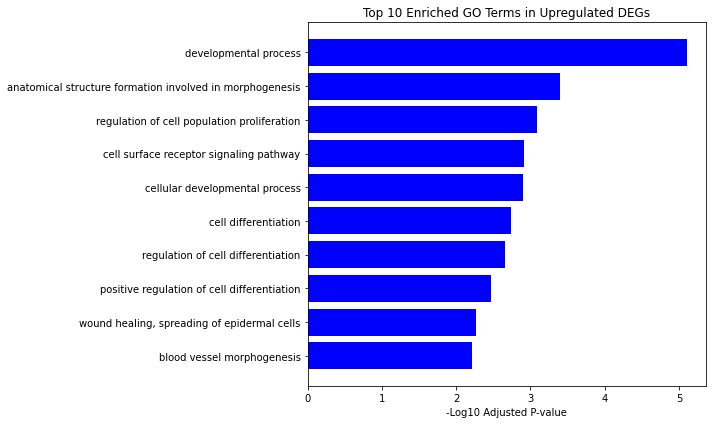

In [16]:
# Plot significant GOs for upregulated gene
# Select top 10 GO terms
top_terms = results_df_upregulated_DEGs.sort_values('p_fdr_bh').head(10)

# Reverse the order for better visualization
top_terms = top_terms[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_terms['name'], -np.log10(top_terms['p_fdr_bh']), color='blue')
plt.xlabel('-Log10 Adjusted P-value')
plt.title('Top 10 Enriched GO Terms in Upregulated DEGs')
plt.tight_layout()

plt.savefig('/Bioinformatics_D/Figures/GO day10.pdf', bbox_inches='tight', dpi=300)
plt.savefig('/Bioinformatics_D/Figures/GO day10.png', bbox_inches='tight', dpi=300)
plt.show()

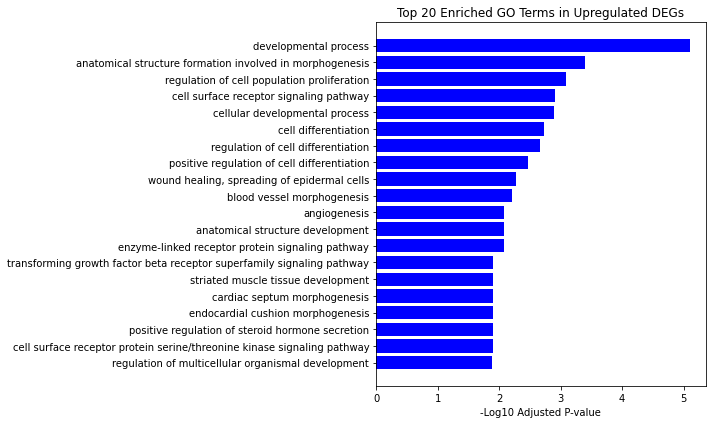

In [17]:
# Plot significant GOs for upregulated gene
# Select top 20 GO terms
top_terms = results_df_upregulated_DEGs.sort_values('p_fdr_bh').head(20)

# Reverse the order for better visualization
top_terms = top_terms[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_terms['name'], -np.log10(top_terms['p_fdr_bh']), color='blue')
plt.xlabel('-Log10 Adjusted P-value')
plt.title('Top 20 Enriched GO Terms in Upregulated DEGs')
plt.tight_layout()

plt.savefig('/Bioinformatics_D/Figures/GO day10 2.pdf', bbox_inches='tight', dpi=300)
plt.savefig('/Bioinformatics_D/Figures/GO day10 2.png', bbox_inches='tight', dpi=300)
plt.show()

In [30]:
# Plot significant GOs for downregulated gene
# Select top 10 GO terms
top_terms = results_df_downregulated_DEGs.sort_values('p_fdr_bh')#.head(10)

# Reverse the order for better visualization
top_terms = top_terms[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_terms['name'], -np.log10(top_terms['p_fdr_bh']), color='blue')
plt.xlabel('-Log10 Adjusted P-value')
plt.title('Top 10 Enriched GO Terms in Downregulated DEGs')
plt.tight_layout()
plt.show()

KeyError: 'p_fdr_bh'

In [ ]:
results_df_downregulated_DEGs

In [ ]:
results_df_upregulated_DEGs